[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CJosh88/ML/blob/main/experiments/2026-10-kumo-tabular/notebook.ipynb)

Standalone Colab notebook. It needs no repo checkout. Runtime: **GPU (T4 is enough)**.

**Question:** with zero tuning, does a pretrained tabular foundation model (NVIDIA Kumo Tabular) beat default XGBoost and LightGBM on small and medium classification tables, and how does it compare with the hand-tuned models from my [2020 Bank Marketing notebook](https://github.com/CJosh88/scriptz/blob/master/Bank%20Marketing%20ML.ipynb)?

| Model | Params | Type | Source | Licence |
|---|---|---|---|---|
| Kumo Tabular small / large | 28M / 215M | In-context learning transformer, pretrained only on synthetic tables, no training on your data | [`nvidia/Kumo-Tabular`](https://huggingface.co/nvidia/Kumo-Tabular) via [`structured-data-models`](https://github.com/NVIDIA/structured-data-models) | OpenMDW-1.1 (weights), Apache-2.0 (code) |
| TabICLv2 | n/a | Earlier in-context tabular model, same library and interface | [`structured-data-models`](https://github.com/NVIDIA/structured-data-models) | BSD-3-Clause (derived code) |
| XGBoost, LightGBM | n/a | Gradient-boosted trees, library defaults | PyPI | Apache-2.0 / MIT |

**TL;DR:** with zero tuning, Kumo Tabular large beat default XGBoost and LightGBM on 25 of 25 splits across five OpenML datasets (+0.034 ROC-AUC on average). The gain was biggest with little data. On Bank Marketing it had the best PR-AUC, ahead of my tuned 2020 XGBoost, but it was about 250× slower than XGBoost on a 10k-row table. A shuffled-label control found no sign of memorisation. Full write-up: [README](https://github.com/CJosh88/ML/tree/main/experiments/2026-10-kumo-tabular).

## Why this matters

Gradient-boosted trees have been the default answer for tabular data for a decade. Tabular foundation models (TabPFN, TabICL and now Kumo Tabular) take a different route: one transformer, pretrained on millions of synthetic tables drawn from structural causal models, that "learns" a new dataset purely in context. You pass the training rows and the rows to predict in one forward pass, with no gradient steps or hyperparameter search.

NVIDIA reports that Kumo Tabular ranks first on TabArena (ELO 1950) and TALENT ([blog](https://huggingface.co/blog/nvidia/kumo-tabular)). This notebook checks that claim on a few public datasets on a free Colab GPU, then reruns a real project of mine from 2020: the hand-tuned logistic regression, random forest (with SMOTE) and XGBoost models on UCI Bank Marketing.

Version note: `structured-data-models` is alpha and **not usable from PyPI** (the PyPI name is a `0.0.0a0` placeholder). This notebook installs it from GitHub, pinned to commit `ce95710`. The blog post's code snippet also has typos (`pd.load_csv`, `drop_column`); the code below follows the repo's own examples.

## Setup

In [1]:
%pip install -q "structured-data-models @ git+https://github.com/NVIDIA/structured-data-models.git@ce95710703a8be5744c756cd2f662ed79d3ee444" "xgboost==3.4.1" "lightgbm==4.7.0" "imbalanced-learn==0.14.2"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 113.0 MB/s eta 0:00:00


In [2]:
import gc, json, random, time, warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn, imblearn
import torch, xgboost as xgb
import sdm
from imblearn.over_sampling import SMOTE
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, f1_score, log_loss,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("sdm", getattr(sdm, "__version__", "?"), "| torch", torch.__version__, "| xgboost", xgb.__version__,
      "| lightgbm", lgb.__version__, "| scikit-learn", sklearn.__version__, "| imbalanced-learn", imblearn.__version__)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0), f"({torch.cuda.get_device_properties(0).total_memory / 2**30:.0f} GiB)")
else:
    print("No GPU found. Kumo Tabular will run on CPU, which is only practical with QUICK = True.")

sdm 0.1.0rc2.dev192+gce9571070 | torch 2.11.0+cu130 | xgboost 3.4.1 | lightgbm 4.7.0 | scikit-learn 1.6.1 | imbalanced-learn 0.14.2
GPU: Tesla T4 (15 GiB)


## Config

Everything tunable lives here. `QUICK = True` shrinks every dataset so the whole notebook runs in a few minutes; use it to check the pipeline, never for results.

In [3]:
QUICK = False

# Part A: OpenML-CC18 benchmark (all binary classification, all licensed "Public" on OpenML)
OPENML_DATASETS = {          # name: OpenML data id
    "credit-g": 31,          # 1,000 rows, 20 features, mostly categorical
    "diabetes": 37,          # 768 rows, 8 numeric features
    "kc1": 1067,             # 2,109 rows, 21 numeric features (software defects)
    "phoneme": 1489,         # 5,404 rows, 5 numeric features
    "adult": 1590,           # 48,842 rows, 14 mixed features, has missing values
}
N_SPLITS = 5                 # stratified random train/test splits per dataset
TEST_FRACTION = 0.25
MAX_TRAIN_ROWS = 10_000      # training rows are subsampled to this (only adult is affected)
MAX_TEST_ROWS = 5_000

# Learning curve: how does each model do as the training set grows?
LC_DATASETS = ["adult", "bank (no duration)"]
LC_SIZES = [100, 300, 1_000, 3_000, 10_000]
LC_SEEDS = 3

# Part B: Bank Marketing rematch (same CSV as the 2020 notebook)
BANK_URL = "https://raw.githubusercontent.com/CJosh88/scriptz/master/bank-full.csv"
OLD_SPLIT_SEED = 20          # the 2020 notebook's train_test_split random_state
RERUN_OLD_SEARCH = False     # True re-runs the 2020 RandomizedSearchCV grids (about 10 extra CPU minutes)

# Foundation models
KUMO_SIZES = ["small", "large"]
NUM_ESTIMATORS = 8           # ensemble members per prediction (NVIDIA's benchmark uses 16 for Kumo)
MAX_CONTEXT = 10_000         # training rows per member; bigger tables get a different random subsample per member
QUERY_CHUNK = 2_048          # rows predicted per forward pass; halved automatically on CUDA out-of-memory
AMP_DTYPE = torch.float16    # matches NVIDIA's benchmark; T4 has no bf16

USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/ML/2026-10-kumo-tabular")
else:
    BASE_DIR = Path(".")
CACHE_DIR = BASE_DIR / "cache"
FIG_DIR = BASE_DIR / "figures"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if QUICK:
    N_SPLITS, LC_SEEDS, LC_SIZES = 1, 1, [100, 300]
    MAX_TRAIN_ROWS, MAX_TEST_ROWS, NUM_ESTIMATORS, MAX_CONTEXT = 400, 200, 2, 300
    KUMO_SIZES = ["small"]
    CACHE_DIR = CACHE_DIR / "quick"; CACHE_DIR.mkdir(exist_ok=True)

## Data

### Part A: OpenML-CC18 datasets

In [4]:
def load_openml(data_id):
    """Returns (X, y) with categoricals as pandas 'category' and y encoded 0..k-1."""
    bunch = fetch_openml(data_id=data_id, as_frame=True, parser="auto")
    X = bunch.data.copy()
    for c in X.columns:
        if X[c].dtype == object or str(X[c].dtype) == "string":
            X[c] = X[c].astype("category")
    y = pd.Series(LabelEncoder().fit_transform(bunch.target.astype(str)), index=X.index, name="target")
    return X.reset_index(drop=True), y.reset_index(drop=True)


DATA = {}
for name, data_id in OPENML_DATASETS.items():
    X, y = load_openml(data_id)
    DATA[name] = (X, y)
    n_cat = sum(str(t) == "category" for t in X.dtypes)
    print(f"{name:10s} {X.shape[0]:>6,} rows  {X.shape[1]:>2} features ({n_cat} categorical)  "
          f"positive rate {y.mean():.2f}  missing cells {int(X.isna().sum().sum()):,}")

DATA["credit-g"][0].head(3)

credit-g    1,000 rows  20 features (13 categorical)  positive rate 0.70  missing cells 0
diabetes      768 rows   8 features (0 categorical)  positive rate 0.35  missing cells 0
kc1         2,109 rows  21 features (0 categorical)  positive rate 0.15  missing cells 0
phoneme     5,404 rows   5 features (0 categorical)  positive rate 0.29  missing cells 0
adult      48,842 rows  14 features (8 categorical)  positive rate 0.24  missing cells 6,465


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes


### Part B: Bank Marketing

In [5]:
bank_raw = pd.read_csv(BANK_URL, sep=";")
print(bank_raw.shape)
print(bank_raw["y"].value_counts().to_string())
bank_raw.head(3)

(45211, 17)
y
no     39922
yes     5289


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


**Licences and citations.** OpenML lists all five Part A datasets as *Public*. Bank Marketing is from the [UCI repository](https://archive.ics.uci.edu/dataset/222/bank+marketing) under CC BY 4.0: S. Moro, P. Cortez and P. Rita (2014), *A Data-Driven Approach to Predict the Success of Bank Telemarketing*, Decision Support Systems 62:22–31. The CSV loaded here is the same `bank-full.csv` (45,211 rows) used in the 2020 notebook.

**A caveat the 2020 notebook missed.** UCI's description of this dataset says `duration` (call length) "highly affects the output target... yet the duration is not known before a call is performed... this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model." The 2020 models used it. Part B therefore runs twice: once with the 2020 feature set (like for like) and once without `duration` (the realistic task).

In [6]:
def old_preprocess(raw):
    """The 2020 notebook's preprocessing, with pandas calls updated. Returns the frame before one-hot encoding."""
    data = raw.sample(frac=1, random_state=SEED).reset_index(drop=True)  # 2020 shuffled without a seed
    data = data.rename(columns={"campaign": "num_of_calls", "previous": "prev_contacts", "y": "outcome"})
    data["duration"] = (data["duration"] / 60).round(2)               # seconds -> minutes
    data = data.drop(columns=["prev_contacts", "month", "day", "contact", "poutcome"])
    for c in ["default", "housing", "loan", "outcome"]:                # 2020: data.replace(['no','yes'], [0,1])
        data[c] = data[c].map({"no": 0, "yes": 1})
    return data


bank = old_preprocess(bank_raw)
y_bank = bank.pop("outcome")
X_bank_raw = bank.copy()                                              # raw categoricals, for Kumo / TabICL / GBDTs
for c in ["job", "marital", "education"]:
    X_bank_raw[c] = X_bank_raw[c].astype("category")

# 2020 encoding for LR / RF / XGB: one-hot (drop_first) then StandardScaler fitted on all rows, as in 2020
X_bank_ohe = pd.get_dummies(bank, prefix_sep="_", drop_first=True).astype(float)
X_bank_scaled = pd.DataFrame(StandardScaler().fit_transform(X_bank_ohe), columns=X_bank_ohe.columns)

idx_train, idx_test = train_test_split(np.arange(len(bank)), test_size=0.20, random_state=OLD_SPLIT_SEED)
print("features (raw):", list(X_bank_raw.columns))
print("features (2020 one-hot):", X_bank_scaled.shape[1], "| train", len(idx_train), "| test", len(idx_test),
      "| test positive rate", round(y_bank.iloc[idx_test].mean(), 3))

DATA["bank (no duration)"] = (X_bank_raw.drop(columns=["duration"]), y_bank)   # used in the learning curve

features (raw): ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'duration', 'num_of_calls', 'pdays']
features (2020 one-hot): 24 | train 36168 | test 9043 | test positive rate 0.117


## Baseline: gradient-boosted trees at library defaults

Both use their native categorical handling. No tuning, no early stopping, no class weights.

In [7]:
def fit_predict_xgb(Xtr, ytr, Xte, seed):
    m = xgb.XGBClassifier(tree_method="hist", enable_categorical=True, random_state=seed, n_jobs=-1)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]


def fit_predict_lgb(Xtr, ytr, Xte, seed):
    m = lgb.LGBMClassifier(random_state=seed, n_jobs=-1, verbose=-1)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]

## New approach: Kumo Tabular (and TabICLv2) by in-context learning

Same interface as the baselines: training rows in, test probabilities out. Nothing is trained. Each call:

1. converts the frames to `sdm.TableTensor`s, with column types from `sdm.infer_stypes` (categoricals stay categorical);
2. if the training set is larger than `MAX_CONTEXT`, gives each ensemble member its own random subsample of it (the approach NVIDIA's benchmark code uses);
3. predicts the test rows in chunks, reusing the same random seed per chunk so every chunk sees identical preprocessing.

In [8]:
FM_MODELS = {}
for size in KUMO_SIZES:
    t = time.time()
    FM_MODELS[f"kumo-{size}"] = sdm.models.KumoTabular(task="classification", size=size, device=DEVICE)
    print(f"loaded kumo-{size} in {time.time() - t:.0f}s")
t = time.time()
FM_MODELS["tabiclv2"] = sdm.models.TabICLv2(device=DEVICE)
print(f"loaded tabiclv2 in {time.time() - t:.0f}s")


def fit_predict_fm(model, Xtr, ytr, Xte, seed, num_estimators=None, max_context=None, chunk=None):
    """Positive-class probabilities from an sdm in-context model."""
    E = num_estimators or NUM_ESTIMATORS
    M = max_context or MAX_CONTEXT
    chunk = chunk or QUERY_CHUNK
    stypes = sdm.infer_stypes(Xtr)
    xc = sdm.TableTensor.from_pandas(df=Xtr.reset_index(drop=True), stypes=stypes, device=DEVICE)
    yc = sdm.TableTensor.from_pandas(df=pd.DataFrame({"target": np.asarray(ytr)}),
                                     stypes={"target": "categorical"}, device=DEVICE)
    xq = sdm.TableTensor.from_pandas(df=Xte.reset_index(drop=True), stypes=stypes, device=DEVICE)

    subsample = len(Xtr) > M
    if subsample:
        g = torch.Generator(DEVICE).manual_seed(seed)
        reps = -(-E * M // len(Xtr))
        perm = torch.cat([torch.randperm(len(Xtr), generator=g, device=DEVICE) for _ in range(reps)])[: E * M]
        xc, yc = xc[perm].unflatten(0, (E, M)), yc[perm].unflatten(0, (E, M))

    probs, start = [], 0
    while start < len(Xte):
        q = xq[start:start + chunk]
        if subsample:
            q = q.expand(E, *q.size())
        try:
            with torch.amp.autocast(DEVICE.type, AMP_DTYPE, enabled=DEVICE.type == "cuda"):
                out = model(x_context=xc, y_context=yc, x_query=q,
                            num_estimators=None if subsample else E, estimator_batch_size=1,
                            generator=torch.Generator(DEVICE).manual_seed(seed))
        except torch.OutOfMemoryError:
            torch.cuda.empty_cache()
            if chunk == 1:
                raise
            chunk = max(1, chunk // 2)
            print(f"  CUDA out of memory, retrying with QUERY_CHUNK={chunk}")
            continue
        col = out.columns[sdm.Stype.numerical].index("1")
        probs.append(out.numerical[..., col].float().cpu().numpy().reshape(-1))
        start += q.size(-2)
    return np.concatenate(probs)


MODELS = {
    "xgboost (default)": fit_predict_xgb,
    "lightgbm (default)": fit_predict_lgb,
    **{name: (lambda m: lambda Xtr, ytr, Xte, seed: fit_predict_fm(m, Xtr, ytr, Xte, seed))(m)
       for name, m in FM_MODELS.items()},
}
print(list(MODELS))

small/classifier.pt: reconstructing file:   0%|          |  0.00B /  110MB            

small/classifier.pt: downloading bytes:           |  0.00B            

loaded kumo-small in 10s


large/classifier.pt: reconstructing file:   0%|          |  0.00B /  855MB            

large/classifier.pt: downloading bytes:           |  0.00B            

...

tabicl-regressor-v2-20260212.ckpt: reconstructing file:   0%|          |  0.00B /  114MB            

tabicl-regressor-v2-20260212.ckpt: downloading bytes:           |  0.00B            

tabicl-classifier-v2-20260212.ckpt: reconstructing file:   0%|          |  0.00B /  110MB            

tabicl-classifier-v2-20260212.ckpt: downloading bytes:           |  0.00B            

loaded tabiclv2 in 5s
['xgboost (default)', 'lightgbm (default)', 'kumo-small', 'kumo-large', 'tabiclv2']


## Evaluation

Every result is cached to `cache/*.json` as soon as it is computed, so a Colab disconnect only loses the run in progress (set `USE_DRIVE = True` to keep the cache across sessions). Timing covers fit plus predict and excludes loading weights. For the in-context models, "fit" and "predict" are the same forward pass.

In [9]:
def sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


def cached(key, fn):
    path = CACHE_DIR / (key.replace("/", "_").replace(" ", "_") + ".json")
    if path.exists():
        return json.loads(path.read_text())
    out = fn()
    path.write_text(json.dumps(out))
    return out


def timed_proba(fit_predict, Xtr, ytr, Xte, seed):
    sync(); t = time.perf_counter()
    p = fit_predict(Xtr, ytr, Xte, seed)
    sync()
    return p, time.perf_counter() - t


def scores(y, p, threshold=0.5):
    pred = (p >= threshold).astype(int)
    return {"accuracy": accuracy_score(y, pred), "roc_auc": roc_auc_score(y, p),
            "pr_auc": average_precision_score(y, p), "log_loss": log_loss(y, np.clip(p, 1e-6, 1 - 1e-6)),
            "precision": precision_score(y, pred, zero_division=0), "recall": recall_score(y, pred),
            "f1": f1_score(y, pred)}


def subsample_rows(idx, n, seed, y):
    if len(idx) <= n:
        return idx
    keep, _ = train_test_split(idx, train_size=n, random_state=seed, stratify=y.iloc[idx])
    return keep

### Part A: five OpenML datasets × `N_SPLITS` splits × five models

In [10]:
rows = []
for name in OPENML_DATASETS:
    X, y = DATA[name]
    splitter = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=TEST_FRACTION, random_state=SEED)
    for split, (tr, te) in enumerate(splitter.split(X, y)):
        tr = subsample_rows(tr, MAX_TRAIN_ROWS, SEED + split, y)
        te = subsample_rows(te, MAX_TEST_ROWS, SEED + split, y)
        for model_name, fp in MODELS.items():
            def run():
                p, secs = timed_proba(fp, X.iloc[tr], y.iloc[tr], X.iloc[te], SEED + split)
                return {**scores(y.iloc[te].values, p), "seconds": secs, "n_train": len(tr), "n_test": len(te)}
            r = cached(f"A__{name}__{split}__{model_name}", run)
            rows.append({"dataset": name, "split": split, "model": model_name, **r})
            print(f"{name:10s} split {split}  {model_name:20s} AUC {r['roc_auc']:.4f}  {r['seconds']:6.1f}s")
        gc.collect(); torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

res_a = pd.DataFrame(rows)
res_a.to_csv(BASE_DIR / "results_openml.csv", index=False)

credit-g   split 0  xgboost (default)    AUC 0.7503     0.1s
credit-g   split 0  lightgbm (default)   AUC 0.7595     0.1s
credit-g   split 0  kumo-small           AUC 0.8040    11.8s
credit-g   split 0  kumo-large           AUC 0.8042     1.8s
credit-g   split 0  tabiclv2             AUC 0.8014     0.4s
credit-g   split 1  xgboost (default)    AUC 0.7693     0.1s
credit-g   split 1  lightgbm (default)   AUC 0.7494     0.1s
credit-g   split 1  kumo-small           AUC 0.7963     0.6s
credit-g   split 1  kumo-large           AUC 0.7992     1.2s
credit-g   split 1  tabiclv2             AUC 0.7916     0.4s
credit-g   split 2  xgboost (default)    AUC 0.7908     0.1s
credit-g   split 2  lightgbm (default)   AUC 0.8071     0.1s
credit-g   split 2  kumo-small           AUC 0.8264     0.5s
credit-g   split 2  kumo-large           AUC 0.8346     1.3s
credit-g   split 2  tabiclv2             AUC 0.8167     0.5s
credit-g   split 3  xgboost (default)    AUC 0.7469     0.1s
credit-g   split 3  ligh

### Learning curve: does the in-context model win more at small sample sizes?

In [11]:
LC_MODELS = ["xgboost (default)", "lightgbm (default)", f"kumo-{KUMO_SIZES[-1]}"]
rows = []
for name in LC_DATASETS:
    X, y = DATA[name]
    for seed in range(LC_SEEDS):
        tr_full, te = train_test_split(np.arange(len(X)), test_size=TEST_FRACTION, random_state=SEED + seed, stratify=y)
        te = subsample_rows(te, MAX_TEST_ROWS, SEED + seed, y)
        for n in LC_SIZES:
            tr = subsample_rows(tr_full, n, SEED + seed, y)
            for model_name in LC_MODELS:
                def run():
                    p, secs = timed_proba(MODELS[model_name], X.iloc[tr], y.iloc[tr], X.iloc[te], SEED + seed)
                    return {**scores(y.iloc[te].values, p), "seconds": secs}
                r = cached(f"LC__{name}__{seed}__{n}__{model_name}", run)
                rows.append({"dataset": name, "seed": seed, "n_train": n, "model": model_name, **r})
        print(f"{name}: seed {seed} done")

res_lc = pd.DataFrame(rows)
res_lc.to_csv(BASE_DIR / "results_learning_curve.csv", index=False)

adult: seed 0 done
adult: seed 1 done
adult: seed 2 done
bank (no duration): seed 0 done
bank (no duration): seed 1 done
bank (no duration): seed 2 done


### Part B: the 2020 Bank Marketing models, rebuilt

The 2020 notebook ran `RandomizedSearchCV` for each model and saved the best estimator. By default this section refits each model with **the best hyperparameters that search found in 2020** (printed in that notebook), on the 2020 split (`random_state=20`, 80/20) and 2020 encoding (one-hot, standardised). Set `RERUN_OLD_SEARCH = True` to rerun the original search grids instead.

| 2020 model | Training data | Best params found in 2020 |
|---|---|---|
| Logistic regression | train | `C=1, max_iter=200` |
| Logistic regression + SMOTE | SMOTE-oversampled train | `C=0.01, max_iter=200` |
| Random forest + SMOTE | SMOTE-oversampled train | `criterion='entropy', max_features='sqrt', max_depth=16` |
| XGBoost (cost-sensitive) | train | `scale_pos_weight=neg/pos, n_estimators=1000, eta=0.01, max_depth=7, gamma=3, reg_alpha=2, reg_lambda=3, subsample=1` |

The 2020 code used APIs that no longer exist (`sklearn.externals.joblib`, `SMOTE.fit_sample`, `plot_precision_recall_curve`), so it cannot be rerun as-is.

In [12]:
REPORTED_2020 = pd.DataFrame({   # printed in the 2020 notebook (threshold 0.5, its own unseeded shuffle)
    "model": ["LogisticReg", "LogisticRegSMOTE", "RandomForest", "XGBoost"],
    "accuracy": [0.89, 0.80, 0.90, 0.88], "precision": [0.58, 0.34, 0.54, 0.49],
    "recall": [0.20, 0.76, 0.84, 0.91], "f1": [0.30, 0.47, 0.65, 0.64],
}).set_index("model")


def old_models(Xtr, ytr, seed=SEED):
    """The four 2020 models, fitted on (one-hot, scaled) Xtr."""
    Xtr_res, ytr_res = SMOTE(random_state=2468).fit_resample(Xtr, ytr)
    neg, pos = np.bincount(ytr)
    xgb_2020 = xgb.XGBClassifier(objective="binary:logistic", tree_method="hist", scale_pos_weight=neg / pos,
                                 n_estimators=1000, random_state=seed, n_jobs=-1)
    if RERUN_OLD_SEARCH:
        lr_grid = {"max_iter": [200, 400, 600, 800], "C": [.01, 0.5, 1]}
        lr1 = RandomizedSearchCV(LogisticRegression(penalty="l2"), lr_grid, cv=5, n_iter=12, n_jobs=-1, random_state=1205).fit(Xtr, ytr).best_estimator_
        lr2 = RandomizedSearchCV(LogisticRegression(penalty="l2"), lr_grid, cv=5, n_iter=12, n_jobs=-1, random_state=1304).fit(Xtr_res, ytr_res).best_estimator_
        rf = RandomizedSearchCV(RandomForestClassifier(criterion="entropy", random_state=seed),
                                {"max_features": ["sqrt", "log2"], "max_depth": [10, 12, 14, 16]},
                                cv=5, n_iter=8, n_jobs=-1, random_state=5074).fit(Xtr_res, ytr_res).best_estimator_
        xgb_grid = {"learning_rate": [0.001, 0.01, 0.1], "max_depth": [6, 7, 8], "gamma": [1, 2, 3],
                    "reg_alpha": [0, 1, 2], "reg_lambda": [1, 2, 3], "subsample": [.5, .75, 1]}
        xg = RandomizedSearchCV(xgb_2020, xgb_grid, scoring="roc_auc", cv=3, n_iter=30, n_jobs=-1,
                                random_state=2054).fit(Xtr, ytr).best_estimator_
    else:
        lr1 = LogisticRegression(C=1, max_iter=200).fit(Xtr, ytr)
        lr2 = LogisticRegression(C=0.01, max_iter=200).fit(Xtr_res, ytr_res)
        rf = RandomForestClassifier(criterion="entropy", max_features="sqrt", max_depth=16,
                                    random_state=seed, n_jobs=-1).fit(Xtr_res, ytr_res)
        xg = xgb_2020.set_params(learning_rate=0.01, max_depth=7, gamma=3, reg_alpha=2, reg_lambda=3, subsample=1).fit(Xtr, ytr)
    return {"LogisticReg": lr1, "LogisticRegSMOTE": lr2, "RandomForest": rf, "XGBoost": xg}


BANK_PRED = {}   # (variant, model) -> test probabilities, for curves and qualitative examples
rows = []
y_tr, y_te = y_bank.iloc[idx_train].values, y_bank.iloc[idx_test].values
for variant, drop in [("2020 features", []), ("no duration", ["duration"])]:
    Xs = X_bank_scaled.drop(columns=drop)
    Xr = X_bank_raw.drop(columns=drop)

    def run_old():
        sync(); t = time.perf_counter()
        fitted = old_models(Xs.iloc[idx_train], y_tr)
        secs = time.perf_counter() - t
        return {name: {"p": m.predict_proba(Xs.iloc[idx_test])[:, 1].tolist(), "seconds": secs} for name, m in fitted.items()}
    for name, r in cached(f"B__{variant}__2020models__search{int(RERUN_OLD_SEARCH)}", run_old).items():
        BANK_PRED[(variant, name + " (2020)")] = (np.array(r["p"]), r["seconds"])

    for model_name, fp in MODELS.items():
        def run_new():
            p, secs = timed_proba(fp, Xr.iloc[idx_train], y_tr, Xr.iloc[idx_test], SEED)
            return {"p": p.tolist(), "seconds": secs}
        r = cached(f"B__{variant}__{model_name}", run_new)
        BANK_PRED[(variant, model_name)] = (np.array(r["p"]), r["seconds"])
        print(f"{variant:14s} {model_name:20s} done")

for (variant, model_name), (p, secs) in BANK_PRED.items():
    rows.append({"variant": variant, "model": model_name, **scores(y_te, p), "seconds": secs})
res_b = pd.DataFrame(rows)
res_b.to_csv(BASE_DIR / "results_bank.csv", index=False)

2020 features  xgboost (default)    done
2020 features  lightgbm (default)   done
2020 features  kumo-small           done
2020 features  kumo-large           done
2020 features  tabiclv2             done
no duration    xgboost (default)    done
no duration    lightgbm (default)   done
no duration    kumo-small           done
no duration    kumo-large           done
no duration    tabiclv2             done


## Results

### Part A: mean over splits (± standard deviation of ROC-AUC)

In [13]:
summary_a = (res_a.groupby(["dataset", "model"])
             .agg(roc_auc=("roc_auc", "mean"), roc_auc_sd=("roc_auc", "std"), accuracy=("accuracy", "mean"),
                  log_loss=("log_loss", "mean"), seconds=("seconds", "mean"))
             .round(4).reset_index())
display(summary_a.pivot(index="dataset", columns="model", values="roc_auc"))

# Average rank across datasets (1 = best ROC-AUC), the usual way tabular benchmarks summarise
ranks = summary_a.pivot(index="dataset", columns="model", values="roc_auc").rank(axis=1, ascending=False)
print("Mean rank by ROC-AUC (lower is better):")
print(ranks.mean().sort_values().round(2).to_string())
summary_a.to_csv(BASE_DIR / "summary_openml.csv", index=False)

model,kumo-large,kumo-small,lightgbm (default),tabiclv2,xgboost (default)
dataset,,,,,
adult,0.9304,0.9291,0.9217,0.9229,0.9144
credit-g,0.8092,0.8054,0.7702,0.8019,0.7671
diabetes,0.8434,0.8386,0.8029,0.8384,0.7944
kc1,0.8721,0.8661,0.7931,0.8672,0.8088
phoneme,0.9788,0.9761,0.9511,0.9737,0.9523


Mean rank by ROC-AUC (lower is better):
model
kumo-large            1.0
kumo-small            2.2
tabiclv2              2.8
lightgbm (default)    4.4
xgboost (default)     4.6


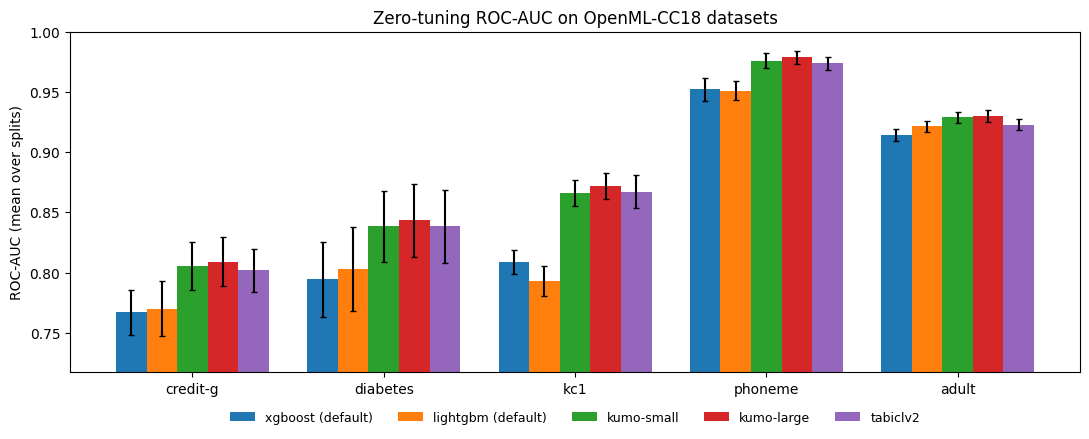

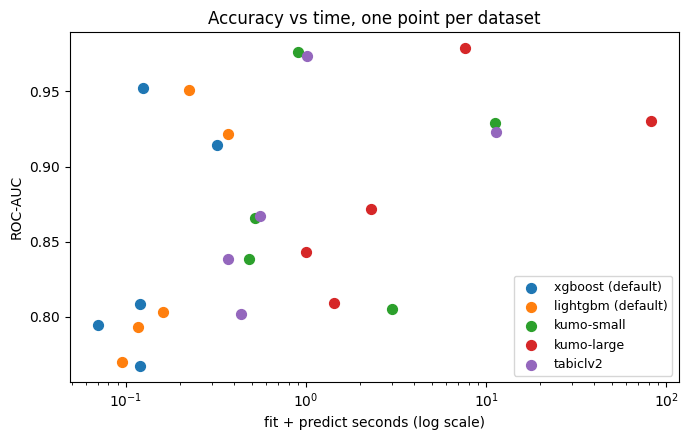

In [14]:
model_order = list(MODELS)
colors = dict(zip(model_order, plt.cm.tab10.colors))
datasets = list(OPENML_DATASETS)
fig, ax = plt.subplots(figsize=(11, 4.5))
w = 0.8 / len(model_order)
for i, m in enumerate(model_order):
    s = summary_a[summary_a.model == m].set_index("dataset").reindex(datasets)
    ax.bar(np.arange(len(datasets)) + i * w, s.roc_auc, w, yerr=s.roc_auc_sd, label=m, color=colors[m], capsize=2)
ax.set_xticks(np.arange(len(datasets)) + w * (len(model_order) - 1) / 2, datasets)
lo = summary_a.roc_auc.min()
ax.set_ylim(max(0.5, lo - 0.05), 1.0)
ax.set_ylabel("ROC-AUC (mean over splits)")
ax.set_title("Zero-tuning ROC-AUC on OpenML-CC18 datasets")
ax.legend(ncol=len(model_order), fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.08), frameon=False)
fig.tight_layout(); fig.savefig(FIG_DIR / "auc_by_dataset.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for m in model_order:
    s = summary_a[summary_a.model == m]
    ax.scatter(s.seconds, s.roc_auc, label=m, color=colors[m], s=50)
ax.set_xscale("log"); ax.set_xlabel("fit + predict seconds (log scale)"); ax.set_ylabel("ROC-AUC")
ax.set_title("Accuracy vs time, one point per dataset"); ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "time_vs_auc.png", dpi=150); plt.show()

### Learning curve

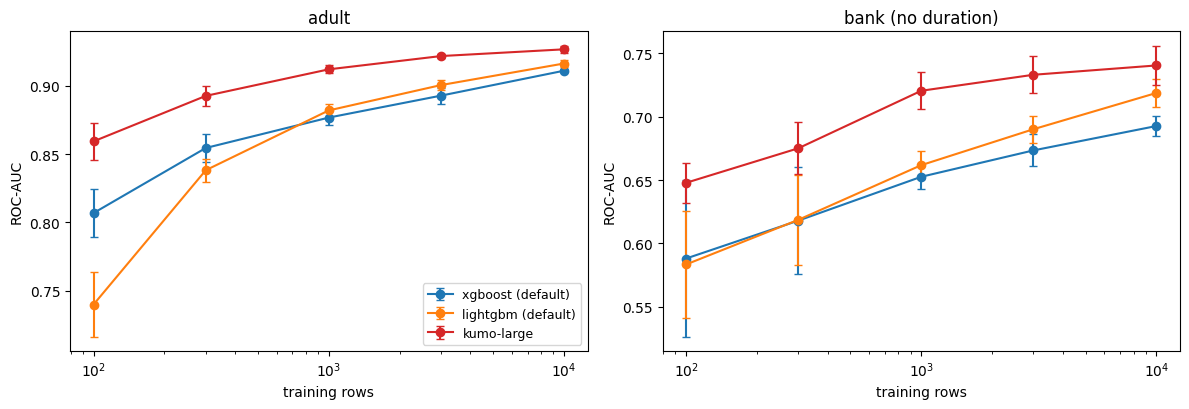

model                       kumo-large  lightgbm (default)  xgboost (default)
dataset            n_train                                                   
adult              100          0.8594              0.7398             0.8069
                   300          0.8927              0.8382             0.8546
                   1000         0.9122              0.8821             0.8768
                   3000         0.9219              0.9007             0.8929
                   10000        0.9269              0.9165             0.9112
bank (no duration) 100          0.6478              0.5835             0.5881
                   300          0.6750              0.6186             0.6180
                   1000         0.7203              0.6617             0.6525
                   3000         0.7329              0.6900             0.6733
                   10000        0.7403              0.7186             0.6926

In [15]:
fig, axes = plt.subplots(1, len(LC_DATASETS), figsize=(12, 4.2), squeeze=False)
for ax, name in zip(axes[0], LC_DATASETS):
    s = res_lc[res_lc.dataset == name].groupby(["model", "n_train"]).roc_auc.agg(["mean", "std"]).reset_index()
    for m in LC_MODELS:
        d = s[s.model == m]
        ax.errorbar(d.n_train, d["mean"], yerr=d["std"], marker="o", capsize=3, label=m, color=colors[m])
    ax.set_xscale("log"); ax.set_xlabel("training rows"); ax.set_ylabel("ROC-AUC"); ax.set_title(name)
axes[0][0].legend(fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "learning_curve.png", dpi=150); plt.show()
display(res_lc.pivot_table(index=["dataset", "n_train"], columns="model", values="roc_auc").round(4))

### Leakage control: shuffled labels

All six datasets are classic public benchmarks. Kumo Tabular is reportedly pretrained only on synthetic tables, but a sceptic could ask whether its advantage comes from having effectively seen these datasets before, either directly or through benchmark-driven design choices.

This control gives each model the same training rows with **randomly permuted labels** (same class balance, no relationship to the features). A model that learns from the context it is given should fall to ROC-AUC ≈ 0.5. A model that "recognises" the dataset and recalls the answers would keep scoring well. XGBoost is included as a reference that cannot have memorised anything.

To keep it cheap, each dataset uses split 0 with at most `SL_TRAIN_ROWS` training rows and `SL_TEST_ROWS` test rows, with `SL_SEEDS` different permutations.

In [16]:
SL_TRAIN_ROWS, SL_TEST_ROWS, SL_SEEDS = (300, 200, 1) if QUICK else (3_000, 2_000, 3)
SL_MODELS = ["xgboost (default)", *[f"kumo-{s}" for s in KUMO_SIZES], "tabiclv2"]
SL_DATASETS = list(OPENML_DATASETS) + ["bank (no duration)"]

rows = []
for name in SL_DATASETS:
    X, y = DATA[name]
    tr, te = next(StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRACTION, random_state=SEED).split(X, y))
    tr = subsample_rows(tr, SL_TRAIN_ROWS, SEED, y)
    te = subsample_rows(te, SL_TEST_ROWS, SEED, y)
    y_true_tr = y.iloc[tr].values
    label_sets = [("true labels", None, y_true_tr)]
    label_sets += [("shuffled labels", s, np.random.default_rng(1000 + s).permutation(y_true_tr)) for s in range(SL_SEEDS)]
    for model_name in SL_MODELS:
        for kind, s, y_ctx in label_sets:
            def run():
                p, secs = timed_proba(MODELS[model_name], X.iloc[tr], y_ctx, X.iloc[te], SEED)
                return {"roc_auc": roc_auc_score(y.iloc[te].values, p), "seconds": secs}
            r = cached(f"SL__{name}__{model_name}__{kind}__{s}", run)
            rows.append({"dataset": name, "model": model_name, "labels": kind, "perm_seed": s, **r})
    print(f"{name}: done")

res_sl = pd.DataFrame(rows)
res_sl.to_csv(BASE_DIR / "results_shuffled_labels.csv", index=False)
sl = res_sl.pivot_table(index=["dataset", "model"], columns="labels", values="roc_auc", aggfunc="mean").round(3)
sl["shuffled max"] = res_sl[res_sl.labels == "shuffled labels"].groupby(["dataset", "model"]).roc_auc.max().round(3)
display(sl)
print("Mean ROC-AUC with shuffled labels, by model:")
print(res_sl[res_sl.labels == "shuffled labels"].groupby("model").roc_auc.agg(["mean", "min", "max"]).round(3).to_string())

credit-g: done
diabetes: done
kc1: done
phoneme: done
adult: done
bank (no duration): done


labels                                shuffled labels  true labels  \
dataset            model                                             
adult              kumo-large                   0.376        0.924   
                   kumo-small                   0.312        0.919   
                   tabiclv2                     0.392        0.910   
                   xgboost (default)            0.500        0.896   
bank (no duration) kumo-large                   0.412        0.749   
                   kumo-small                   0.465        0.753   
                   tabiclv2                     0.448        0.739   
                   xgboost (default)            0.445        0.696   
credit-g           kumo-large                   0.455        0.804   
                   kumo-small                   0.445        0.804   
                   tabiclv2                     0.451        0.801   
                   xgboost (default)            0.485        0.750   
diabetes           kumo-large                   0.624        0.832   
                   kumo-small                   0.549        0.828   
                   tabiclv2                     0.572        0.822   
                   xgboost (default)            0.553        0.792   
kc1                kumo-large                   0.412        0.873   
                   kumo-small                   0.500        0.863   
                   tabiclv2                     0.361        0.866   
                   xgboost (default)            0.353        0.819   
phoneme            kumo-large                   0.573        0.966   
                   kumo-small                   0.406        0.961   
                   tabiclv2                     0.505        0.958   
                   xgboost (default)            0.509        0.929   

labels                                shuffled max  
dataset            model                            
adult              kumo-large                0.489  
                   kumo-small                0.373  
                   tabiclv2                  0.471  
                   xgboost (default)         0.513  
bank (no duration) kumo-large                0.508  
                   kumo-small                0.555  
                   tabiclv2                  0.533  
                   xgboost (default)         0.457  
credit-g           kumo-large                0.590  
                   kumo-small                0.543  
                   tabiclv2                  0.557  
                   xgboost (default)         0.536  
diabetes           kumo-large                0.628  
                   kumo-small                0.561  
                   tabiclv2                  0.657  
                   xgboost (default)         0.561  
kc1                kumo-large                0.627  
                   kumo-small                0.653  
                   tabiclv2                  0.409  
                   xgboost (default)         0.370  
phoneme            kumo-large                0.655  
                   kumo-small                0.496  
                   tabiclv2                  0.623  
                   xgboost (default)         0.547

Mean ROC-AUC with shuffled labels, by model:
                    mean    min    max
model                                 
kumo-large         0.475  0.254  0.655
kumo-small         0.446  0.260  0.653
tabiclv2           0.455  0.277  0.657
xgboost (default)  0.474  0.335  0.561


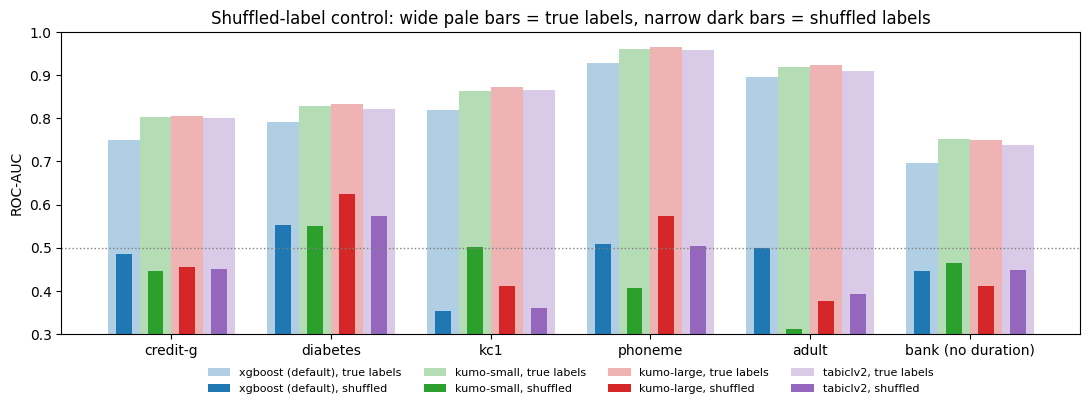

In [17]:
fig, ax = plt.subplots(figsize=(11, 4.2))
w = 0.8 / len(SL_MODELS)
for i, m in enumerate(SL_MODELS):
    d = res_sl[res_sl.model == m]
    true = d[d.labels == "true labels"].set_index("dataset").roc_auc.reindex(SL_DATASETS)
    shuf = d[d.labels == "shuffled labels"].groupby("dataset").roc_auc.mean().reindex(SL_DATASETS)
    x = np.arange(len(SL_DATASETS)) + i * w
    ax.bar(x, true, w, color=colors[m], alpha=0.35, label=f"{m}, true labels")
    ax.bar(x, shuf, w * 0.5, color=colors[m], label=f"{m}, shuffled")
ax.axhline(0.5, color="grey", ls=":", lw=1)
ax.set_xticks(np.arange(len(SL_DATASETS)) + w * (len(SL_MODELS) - 1) / 2, SL_DATASETS)
ax.set_ylim(0.3, 1.0); ax.set_ylabel("ROC-AUC")
ax.set_title("Shuffled-label control: wide pale bars = true labels, narrow dark bars = shuffled labels")
ax.legend(ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.08), frameon=False)
fig.tight_layout(); fig.savefig(FIG_DIR / "shuffled_labels.png", dpi=150); plt.show()

### Part B: Bank Marketing rematch

The first table puts the 2020 notebook's printed numbers next to today's rebuild of the same models, then adds the zero-tuning models. Threshold-0.5 metrics (accuracy, precision, recall, F1) depend heavily on whether a model was trained to compensate for the 88/12 class imbalance: SMOTE and `scale_pos_weight` push recall up, while the in-context models and default GBDTs are uncorrected. ROC-AUC and PR-AUC (average precision) do not depend on a threshold, so they are the fairer comparison.

In [18]:
show = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "seconds"]
print("As printed in the 2020 notebook:")
display(REPORTED_2020)
for variant in ["2020 features", "no duration"]:
    print(f"\nRebuilt today, {variant}, test set n={len(idx_test):,}:")
    display(res_b[res_b.variant == variant].set_index("model")[show].round(3).sort_values("pr_auc", ascending=False))

As printed in the 2020 notebook:


,accuracy,precision,recall,f1
model,,,,
LogisticReg,0.89,0.58,0.20,0.30
LogisticRegSMOTE,0.80,0.34,0.76,0.47
RandomForest,0.90,0.54,0.84,0.65
XGBoost,0.88,0.49,0.91,0.64



Rebuilt today, 2020 features, test set n=9,043:


,accuracy,precision,recall,f1,roc_auc,pr_auc,seconds
model,,,,,,,
kumo-large,0.903,0.639,0.401,0.492,0.901,0.566,139.846
kumo-small,0.902,0.643,0.380,0.477,0.900,0.564,17.339
tabiclv2,0.903,0.646,0.379,0.478,0.898,0.551,18.230
XGBoost (2020),0.818,0.374,0.811,0.512,0.895,0.542,11.740
lightgbm (default),0.901,0.619,0.396,0.483,0.897,0.540,0.387
xgboost (default),0.896,0.587,0.382,0.463,0.888,0.508,0.426
RandomForest (2020),0.859,0.438,0.710,0.542,0.885,0.492,11.740
LogisticRegSMOTE (2020),0.801,0.344,0.764,0.475,0.864,0.468,11.740
LogisticReg (2020),0.894,0.627,0.228,0.334,0.860,0.466,11.740



Rebuilt today, no duration, test set n=9,043:


,accuracy,precision,recall,f1,roc_auc,pr_auc,seconds
model,,,,,,,
kumo-large,0.888,0.619,0.125,0.208,0.739,0.373,138.419
kumo-small,0.887,0.601,0.112,0.189,0.737,0.356,16.886
lightgbm (default),0.887,0.576,0.124,0.205,0.740,0.351,0.358
XGBoost (2020),0.769,0.267,0.556,0.361,0.733,0.349,10.051
tabiclv2,0.885,0.580,0.082,0.144,0.737,0.344,18.128
xgboost (default),0.885,0.531,0.163,0.249,0.722,0.331,0.404
RandomForest (2020),0.836,0.341,0.428,0.380,0.715,0.310,10.051
LogisticRegSMOTE (2020),0.638,0.189,0.631,0.290,0.691,0.269,10.051
LogisticReg (2020),0.883,0.484,0.014,0.027,0.690,0.268,10.051


### Why the 2020 random forest and XGBoost numbers don't reproduce

Today's rebuild matches 2020 for both logistic regressions, but the 2020 random forest and XGBoost scores come out noticeably lower. A likely cause: the 2020 notebook shuffled the data **without a seed** and evaluated models **loaded from `.pkl` files**. If those pickles were trained in an earlier session, that session's shuffle and split were different, so about 80% of the 2020 "test" rows were training rows for the pickled models. Models that memorise their training data would look better on such a test set, by an amount that depends on how much they memorise; logistic regression would barely change.

The cell below simulates that: train on one shuffle's split, then score on the test split of a different shuffle. Compare its "reshuffled" column with the numbers 2020 printed.

In [19]:
def split_for_shuffle(shuffle_seed):
    d = old_preprocess(bank_raw.sample(frac=1, random_state=shuffle_seed).reset_index(drop=True))
    yy = d.pop("outcome").values
    Xd = StandardScaler().fit_transform(pd.get_dummies(d, prefix_sep="_", drop_first=True).astype(float))
    return train_test_split(Xd, yy, test_size=0.20, random_state=OLD_SPLIT_SEED)

def run_leak_check():
    Xtr_a, Xte_a, ytr_a, yte_a = split_for_shuffle(1)   # "session 1": train and pickle
    _, Xte_b, _, yte_b = split_for_shuffle(2)           # "session 2": reshuffle, reload pickles, evaluate
    fitted = old_models(pd.DataFrame(Xtr_a), ytr_a)
    out = []
    for test_name, Xte, yte in [("clean (same shuffle)", Xte_a, yte_a), ("reshuffled (leaky)", Xte_b, yte_b)]:
        for name, m in fitted.items():
            pred = m.predict(pd.DataFrame(Xte))
            out.append({"test set": test_name, "model": name, "accuracy": accuracy_score(yte, pred),
                        "precision": precision_score(yte, pred), "recall": recall_score(yte, pred), "f1": f1_score(yte, pred)})
    return out

leak = pd.DataFrame(cached("B__leak_check", run_leak_check))
display(leak.pivot_table(index="model", columns="test set", values=["precision", "recall", "f1"]).round(2))
print("2020 notebook printed:"); display(REPORTED_2020)

f1                               precision  \
test set         clean (same shuffle) reshuffled (leaky) clean (same shuffle)   
model                                                                           
LogisticReg                      0.32               0.33                 0.63   
LogisticRegSMOTE                 0.49               0.49                 0.36   
RandomForest                     0.54               0.68                 0.44   
XGBoost                          0.53               0.55                 0.39   

                                                  recall                     
test set         reshuffled (leaky) clean (same shuffle) reshuffled (leaky)  
model                                                                        
LogisticReg                    0.60                 0.21               0.23  
LogisticRegSMOTE               0.35                 0.79               0.79  
RandomForest                   0.56                 0.71               0.86  
XGBoost                        0.40                 0.84               0.88

2020 notebook printed:


,accuracy,precision,recall,f1
model,,,,
LogisticReg,0.89,0.58,0.20,0.30
LogisticRegSMOTE,0.80,0.34,0.76,0.47
RandomForest,0.90,0.54,0.84,0.65
XGBoost,0.88,0.49,0.91,0.64


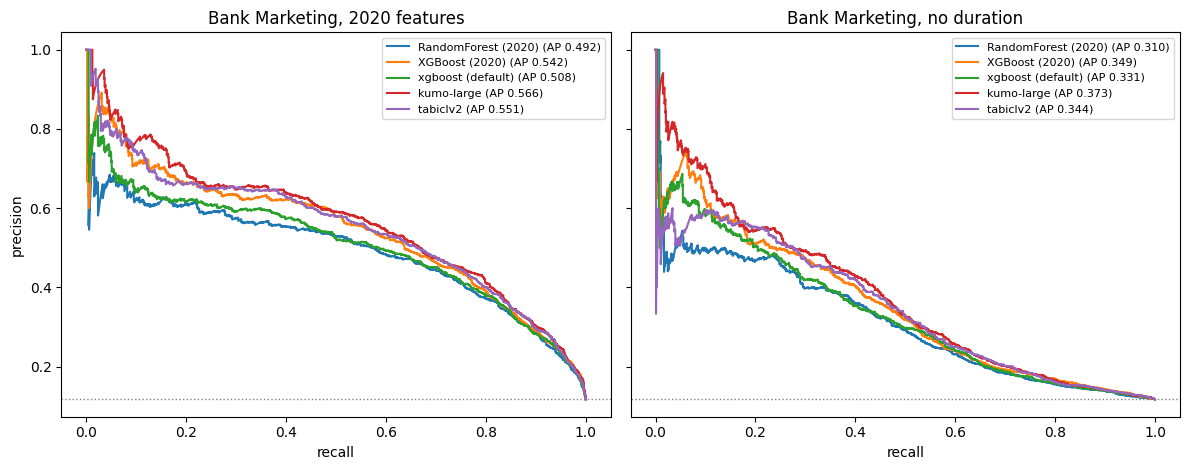

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
pick = ["RandomForest (2020)", "XGBoost (2020)", "xgboost (default)", f"kumo-{KUMO_SIZES[-1]}", "tabiclv2"]
for ax, variant in zip(axes, ["2020 features", "no duration"]):
    for m in pick:
        p, _ = BANK_PRED[(variant, m)]
        prec, rec, _ = precision_recall_curve(y_te, p)
        ax.plot(rec, prec, label=f"{m} (AP {average_precision_score(y_te, p):.3f})")
    ax.axhline(y_te.mean(), color="grey", ls=":", lw=1)
    ax.set_xlabel("recall"); ax.set_title(f"Bank Marketing, {variant}"); ax.legend(fontsize=8)
axes[0].set_ylabel("precision")
fig.tight_layout(); fig.savefig(FIG_DIR / "bank_pr_curves.png", dpi=150); plt.show()

## Qualitative examples

Bank Marketing test rows (realistic `no duration` variant) where the best 2020 model and Kumo disagree most, plus Kumo's most confident mistake.

In [21]:
variant = "no duration"
kumo_name = f"kumo-{KUMO_SIZES[-1]}"
best_2020 = (res_b[(res_b.variant == variant) & res_b.model.str.endswith("(2020)")]
             .sort_values("pr_auc", ascending=False).model.iloc[0])
p_k, _ = BANK_PRED[(variant, kumo_name)]
p_o, _ = BANK_PRED[(variant, best_2020)]
ex = X_bank_raw.drop(columns=["duration"]).iloc[idx_test].reset_index(drop=True).copy()
ex["subscribed"] = y_te
ex[f"p({best_2020})"] = p_o.round(3)
ex[f"p({kumo_name})"] = p_k.round(3)
gap = p_k - p_o
picks = {
    f"{kumo_name} much higher, right": np.where(y_te == 1, gap, -np.inf).argsort()[-2:],
    f"{best_2020} much higher, right": np.where(y_te == 1, -gap, -np.inf).argsort()[-2:],
    f"{kumo_name} most confident mistake": [np.abs(p_k - y_te).argmax()],
}
print("best 2020 model on PR-AUC:", best_2020)
for label, ids in picks.items():
    print("\n" + label)
    display(ex.iloc[list(ids)])

best 2020 model on PR-AUC: XGBoost (2020)

kumo-large much higher, right


,age,job,marital,education,default,balance,housing,loan,num_of_calls,pdays,subscribed,p(XGBoost (2020)),p(kumo-large)
6242,95,retired,divorced,primary,0,2282,0,0,17,-1,1,0.392,0.375
4526,30,management,married,tertiary,0,102,1,0,7,426,1,0.202,0.407



XGBoost (2020) much higher, right


,age,job,marital,education,default,balance,housing,loan,num_of_calls,pdays,subscribed,p(XGBoost (2020)),p(kumo-large)
595,61,retired,divorced,secondary,0,927,0,0,3,-1,1,0.852,0.243
6348,36,technician,divorced,secondary,0,2823,1,0,1,371,1,0.846,0.125



kumo-large most confident mistake


,age,job,marital,education,default,balance,housing,loan,num_of_calls,pdays,subscribed,p(XGBoost (2020)),p(kumo-large)
2525,57,retired,divorced,primary,0,63,0,1,17,-1,1,0.06,0.03


## Interpretation

From the full run on a Colab T4 (the [README](https://github.com/CJosh88/ML/tree/main/experiments/2026-10-kumo-tabular) has all the tables):

1. **For small and medium tables, a pretrained in-context model is now a strong default.** With no tuning, Kumo Tabular beat untuned GBDTs on all 25 splits, often by more than the split-to-split noise. On Bank Marketing it also beat my tuned 2020 XGBoost on PR-AUC.
2. **The less data you have, the bigger the win.** Kumo needed roughly 3–10× fewer rows than the trees to reach the same ROC-AUC. Near the 10k-row context limit, the GBDTs close in.
3. **Kumo small is the practical choice.** It came within 0.004 ROC-AUC of large at about one-eighth of the cost.
4. **Thresholds still need thought.** The in-context models aren't told about class imbalance, so on imbalanced problems pick the operating point from the precision-recall curve rather than using 0.5.
5. **No sign of memorisation.** With shuffled labels, every model, Kumo included, fell to chance or below.
6. **The rematch was most useful for checking my old work.** It surfaced a leaky feature (`duration`) and a train/test leak that likely inflated my 2020 random forest results.

## Limitations and next steps

- **Small benchmark.** Five binary datasets and five splits each; NVIDIA's claims rest on TabArena's 51 datasets. Treat these results as a sanity check, not a ranking.
- **Untuned baselines.** XGBoost and LightGBM use library defaults with no early stopping. Tuned GBDTs would close some of any gap; the comparison is zero-tuning against zero-tuning.
- **Context cap.** Kumo sees at most `MAX_CONTEXT` training rows per ensemble member, so on adult and Bank Marketing it never sees the whole training set at once. NVIDIA benchmarks on much larger GPUs.
- **Fewer ensemble members** than NVIDIA's benchmark (8 vs 16) to fit the Colab budget.
- **Bank rebuild is close to, not identical with, 2020.** The 2020 shuffle had no seed, library versions differ, and by default the 2020 *best* hyperparameters are reused rather than re-searched. The 2020 StandardScaler was fitted on all rows (a small leak) and is kept for fidelity.
- **Timing** mixes a GPU (in-context models) with a 2-vCPU CPU (trees), so it is about practical cost on free Colab, not about algorithms.
- Next: regression on OpenML-CTR23, Kumo `medium`, and `NUM_ESTIMATORS = 16`.

## Environment

In [22]:
!pip freeze | grep -i -E "^(structured-data-models|torch|xgboost|lightgbm|scikit-learn|imbalanced-learn|pandas|numpy)[= @]"

imbalanced-learn==0.14.2
lightgbm==4.7.0
numpy==2.1.3
pandas==2.2.3
scikit-learn==1.6.1
structured-data-models @ git+https://github.com/NVIDIA/structured-data-models.git@ce95710703a8be5744c756cd2f662ed79d3ee444
torch==2.11.0+cu130
xgboost==3.4.1
